# Cohort and Retention Analysis

Clean Data Loaded. Shape: 5630 rows, (5630, 20) columns

TENURE LIFECYCLE COHORT RETENTION TABLE
                 Tenure_Cohort  Total_Customers  Active_Customers  Churned_Customers  Retention_Rate  Churn_Rate  Total_Monetary_Pool  Avg_Satisfaction
          01. 0-3 Months (New)             1560               907                653           58.14       41.86            242836.21          3.178205
        02. 4-6 Months (Early)              590               546                 44           92.54        7.46            100244.54          2.935593
         03. 7-12 Months (Mid)             1584              1428                156           90.15        9.85            258689.28          2.989899
04. 13-24 Months (Established)             1467              1372                 95           93.52        6.48            300611.76          3.087935
       05. 25+ Months (Mature)              429               429                  0          100.00        0.00             95383.87          

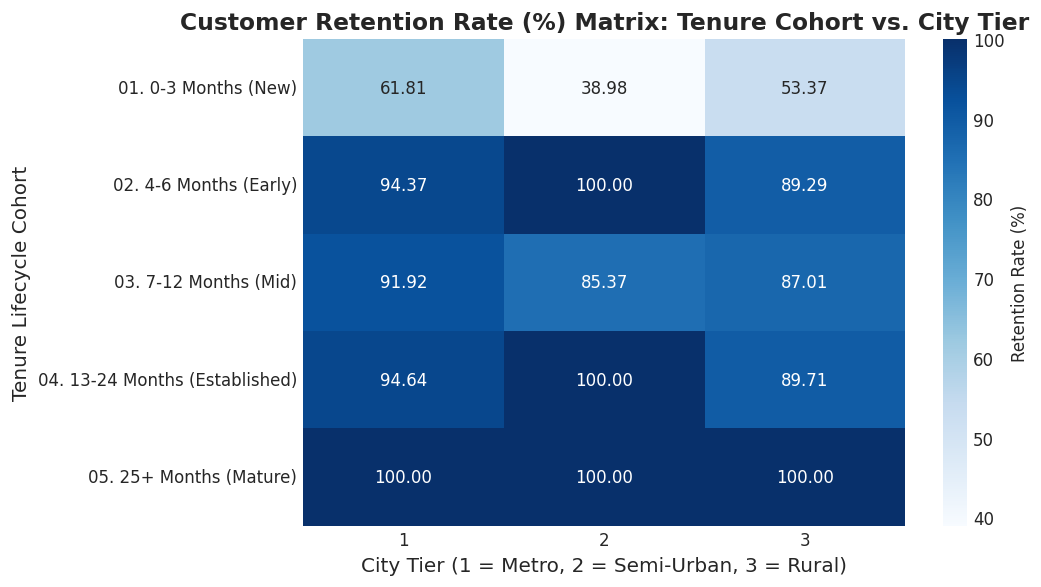

Cohort retention metrics saved to: C:\Users\AADHYA SHARMA\Downloads\customer-churn-revenue-intelligence\data\processed\tenure_cohort_retention.csv


In [1]:
# Step 1: Environment Setup & Explicit Paths
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = r"C:\Users\AADHYA SHARMA\Downloads\customer-churn-revenue-intelligence"
VISUALIZATIONS_DIR = os.path.join(BASE_DIR, "visualizations")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

# Ensure target directories exist
os.makedirs(VISUALIZATIONS_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Step 2: Load Clean Data
CLEAN_DATA_PATH = os.path.join(PROCESSED_DIR, "ecommerce_churn_clean.csv")
df = pd.read_csv(CLEAN_DATA_PATH)
print(f"Clean Data Loaded. Shape: {df.shape[0]} rows, {df.shape} columns")

# Step 3: Define Customer Tenure Lifecycle Cohorts
def assign_tenure_cohort(tenure):
    if tenure <= 3:
        return '01. 0-3 Months (New)'
    elif tenure <= 6:
        return '02. 4-6 Months (Early)'
    elif tenure <= 12:
        return '03. 7-12 Months (Mid)'
    elif tenure <= 24:
        return '04. 13-24 Months (Established)'
    else:
        return '05. 25+ Months (Mature)'

df['Tenure_Cohort'] = df['Tenure'].apply(assign_tenure_cohort)

# Step 4: Calculate Cohort Retention & Churn Metrics
cohort_summary = df.groupby('Tenure_Cohort').agg(
    Total_Customers=('CustomerID', 'count'),
    Active_Customers=('Churn', lambda x: (x == 0).sum()),
    Churned_Customers=('Churn', lambda x: (x == 1).sum()),
    Retention_Rate=('Churn', lambda x: round((x == 0).mean() * 100, 2)),
    Churn_Rate=('Churn', lambda x: round((x == 1).mean() * 100, 2)),
    Total_Monetary_Pool=('CashbackAmount', 'sum'),
    Avg_Satisfaction=('SatisfactionScore', 'mean')
).reset_index()

print("\n" + "="*85)
print("TENURE LIFECYCLE COHORT RETENTION TABLE")
print("="*85)
print(cohort_summary.to_string(index=False))

# Step 5: Multi-Dimensional Cohort Retention Matrix (Tenure Cohort vs City Tier)
cohort_pivot = df.pivot_table(
    index='Tenure_Cohort', 
    columns='CityTier', 
    values='Churn', 
    aggfunc=lambda x: round((1.0 - x.mean()) * 100, 2) # Retention Rate %
)

plt.figure(figsize=(9, 5))
sns.heatmap(cohort_pivot, annot=True, fmt=".2f", cmap='Blues', cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Customer Retention Rate (%) Matrix: Tenure Cohort vs. City Tier', fontsize=14, fontweight='bold')
plt.xlabel('City Tier (1 = Metro, 2 = Semi-Urban, 3 = Rural)', fontsize=12)
plt.ylabel('Tenure Lifecycle Cohort', fontsize=12)
plt.tight_layout()

# Save heatmap using absolute path
heatmap_path = os.path.join(VISUALIZATIONS_DIR, "tenure_retention_heatmap.png")
plt.savefig(heatmap_path, bbox_inches='tight')
print(f"\nHeatmap saved to: {heatmap_path}")
plt.show()

# Step 6: Export Cohort Metrics
cohort_export_path = os.path.join(PROCESSED_DIR, "tenure_cohort_retention.csv")
cohort_summary.to_csv(cohort_export_path, index=False)
print(f"Cohort retention metrics saved to: {cohort_export_path}")